
Model: Logistic Regression
  Train accuracy : 1.0000
  Elapsed        : 0.98s
  P_A shape      : (2781,)


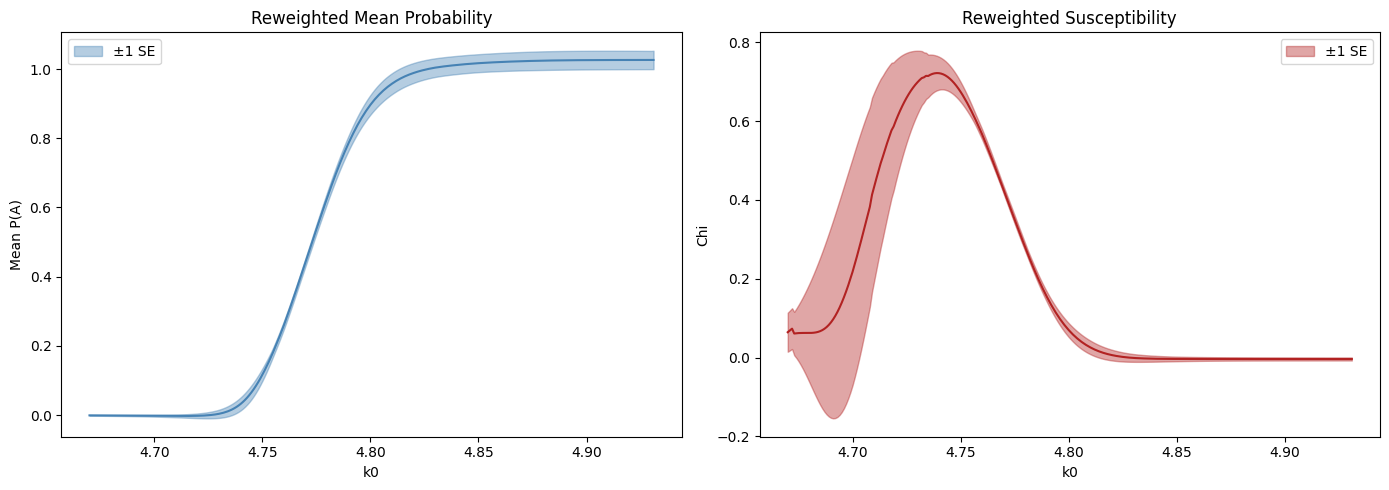

In [1]:
import numpy as np
import time
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# =============================================================================
# DATA LOADING
# =============================================================================

full_R = np.load("../data/c_a/processed/R_dataset_full.npz", allow_pickle=True)
X_full_R  = full_R["X"]
K0_full_R = full_R["K0"]

full_R_477 = np.load("../data/c_a/processed/R_dataset_full_477.npz", allow_pickle=True)
X_full_R_477  = full_R_477["X"]
K0_full_R_477 = full_R_477["K0"]

full_477 = np.load("../data/c_a/processed/dataset_full_k477.npz", allow_pickle=True)
X_full_477  = full_477["X"]
K0_full_477 = full_477["K0"]

# =============================================================================
# BUILD DENSE k-GRID WITH INTERPOLATED k4
# =============================================================================

k0r = np.array(sorted(set(K0_full_R)), dtype=float)
k4r = []
for k in k0r:
    mask = (K0_full_R == k)
    k4_val = X_full_R[mask][0, 2]   # take first value (faster than mean)
    k4r.append(k4_val)
k4r = np.array(k4r)

k_min  = k0r.min()
k_max  = k0r.max()
step   = 0.001
k_uniform = np.round(np.arange(k_min, k_max + step, step), 5)
k_dense   = np.unique(np.concatenate([k_uniform, k0r]))
k_dense   = np.sort(k_dense)
k4_dense  = np.interp(k_dense, k0r, k4r)

# =============================================================================
# TRAINING DATA
# =============================================================================

train   = np.load("../data/c_a/processed/dataset_train_shortened.npz", allow_pickle=True)
X_train = train["X"]
y_train = train["y"]

full    = np.load("../data/c_a/processed/dataset_full.npz", allow_pickle=True)
X_full  = full["X"]
K0_full = full["K0"]

# =============================================================================
# MODEL HELPERS
# =============================================================================

def build_model(base_model, calibrated=False):
    """
    Wrap base_model in a sklearn Pipeline.
    When calibrated=True a CalibratedClassifierCV is added on top.
    """
    if calibrated:
        pipe = Pipeline([
            ("clf", CalibratedClassifierCV(base_model, cv=5, method="isotonic"))
        ])
    else:
        pipe = Pipeline([
            ("clf", base_model)
        ])
    return pipe


def run_supervised_pipeline(model, X_train, y_train, X_eval):
    """
    Fit model on (X_train, y_train) and return predicted probabilities
    on X_eval together with the training accuracy.
    """
    model.fit(X_train, y_train)
    train_score = model.score(X_train, y_train)

    if hasattr(model, "predict_proba"):
        P_A = model.predict_proba(X_eval)[:, 1]
    else:
        scores = model.decision_function(X_eval)
        P_A    = 1.0 / (1.0 + np.exp(-scores))

    return train_score, P_A

# =============================================================================
# FIT MODEL AT k0 = 4.77
# =============================================================================

models = {
    "Logistic Regression": LogisticRegression(),
}

k_target = 4.77
mask_477 = (K0_full == k_target)
X_full_k477 = X_full[mask_477]

# subsample for speed – keep every 100th point
k477 = X_full_k477[::100]

for name, base_model in models.items():
    print(f"\n{'='*50}\nModel: {name}\n{'='*50}")
    model = build_model(base_model, calibrated=False)

    t0 = time.perf_counter()
    train_score, P_A = run_supervised_pipeline(model, X_train, y_train, k477)
    elapsed = time.perf_counter() - t0

    print(f"  Train accuracy : {train_score:.4f}")
    print(f"  Elapsed        : {elapsed:.2f}s")
    print(f"  P_A shape      : {P_A.shape}")

# =============================================================================
# REWEIGHTING REFERENCE POINT
# =============================================================================

k0_ref = 4.77
k4_ref = 1.178870

# observables at the reference point (same subsampling as k477)
n0   = k477[:, 0]
n4   = k477[:, 3]
med0 = np.median(n0)
med4 = np.median(n4)

# =============================================================================
# STATISTICAL ESTIMATORS
# =============================================================================

def stat_reweighted_mean(P, w):
    """Weighted mean of P."""
    return np.sum(P * w) / np.sum(w)


def stat_reweighted_susceptibility(P, w):
    """
    Weighted susceptibility: Var_w(P) / Mean_w(P).
    Returns 0 if the weighted mean is zero to avoid division by zero.
    """
    mean = np.sum(P * w) / np.sum(w)
    if mean == 0.0:
        return 0.0
    var = np.sum(w * (P - mean) ** 2) / np.sum(w)
    return var / mean


def block_jackknife_reweighted(P, w, stat_func, B):
    """
    Block jackknife for a weighted estimator.

    Parameters
    ----------
    P         : 1-D array of probabilities
    w         : 1-D array of weights (same length as P)
    stat_func : callable(P, w) -> scalar
    B         : number of blocks

    Returns
    -------
    (theta_hat, theta_jack, se)
        theta_hat  – full-sample estimate
        theta_jack – bias-corrected jackknife estimate
        se         – jackknife standard error
    Returns None if blocks are too small (m < 2).
    """
    n = len(P)
    m = n // B
    if m < 2:
        return None

    # truncate to an exact multiple of B
    P = P[:m * B]
    w = w[:m * B]

    P_blocks = P.reshape(B, m)
    w_blocks = w.reshape(B, m)

    # full estimator
    theta_hat = stat_func(P, w)

    # leave-one-block-out estimates
    thetas = np.array([
        stat_func(
            np.concatenate([P_blocks[:i], P_blocks[i+1:]]).ravel(),
            np.concatenate([w_blocks[:i], w_blocks[i+1:]]).ravel()
        )
        for i in range(B)
    ])

    theta_bar = np.mean(thetas)

    # bias-corrected estimate
    bias       = (B - 1) * (theta_bar - theta_hat)
    theta_jack = theta_hat - bias

    # jackknife variance / standard error
    var_jack = np.var(thetas, ddof=1) * (B - 1) ** 2 / B
    se       = np.sqrt(var_jack)

    return theta_hat, theta_jack, se

# =============================================================================
# REWEIGHTING + JACKKNIFE LOOP
# =============================================================================

reweightedP   = []
reweightedChi = []

for k0, k4 in zip(k_dense, k4_dense):

    # -------------------------------------------------------------------------
    # Histogram-reweighting weights
    # -------------------------------------------------------------------------
    wght = np.exp(
        (k0 - k0_ref) * (n0 - med0)
        - (k4 - k4_ref) * (n4 - med4)
    )
    wght = wght / np.mean(wght)   # normalise for numerical stability

    # -------------------------------------------------------------------------
    # MEAN  – choose B that gives the most conservative (largest) SE
    # -------------------------------------------------------------------------
    best_mean_se = -np.inf
    best_mean    = None

    for B in range(2, 101):
        out = block_jackknife_reweighted(P_A, wght, stat_reweighted_mean, B)
        if out is None:
            continue
        _, theta_jack, se = out
        if se > best_mean_se:
            best_mean_se = se
            best_mean    = theta_jack

    # -------------------------------------------------------------------------
    # SUSCEPTIBILITY  – same conservative selection strategy
    # -------------------------------------------------------------------------
    best_chi_se = -np.inf
    best_chi    = None

    for B in range(2, 101):
        out = block_jackknife_reweighted(P_A, wght, stat_reweighted_susceptibility, B)
        if out is None:
            continue
        _, theta_jack, se = out
        if se > best_chi_se:
            best_chi_se = se
            best_chi    = theta_jack

    # -------------------------------------------------------------------------
    # Store  [k0, estimate, se]
    # -------------------------------------------------------------------------
    reweightedP.append([k0, best_mean,  best_mean_se])
    reweightedChi.append([k0, best_chi, best_chi_se])

reweightedP   = np.array(reweightedP)
reweightedChi = np.array(reweightedChi)

# =============================================================================
# PLOTTING
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Mean probability ---
ax = axes[0]
ax.set_title("Reweighted Mean Probability")
ax.plot(reweightedP[:, 0], reweightedP[:, 1], color="steelblue", lw=1.5)
ax.fill_between(
    reweightedP[:, 0],
    reweightedP[:, 1] - reweightedP[:, 2],
    reweightedP[:, 1] + reweightedP[:, 2],
    alpha=0.4,
    color="steelblue",
    label="±1 SE"
)
ax.set_xlabel("k0")
ax.set_ylabel("Mean P(A)")
ax.legend()

# --- Susceptibility ---
ax = axes[1]
ax.set_title("Reweighted Susceptibility")
ax.plot(reweightedChi[:, 0], reweightedChi[:, 1], color="firebrick", lw=1.5)
ax.fill_between(
    reweightedChi[:, 0],
    reweightedChi[:, 1] - reweightedChi[:, 2],
    reweightedChi[:, 1] + reweightedChi[:, 2],
    alpha=0.4,
    color="firebrick",
    label="±1 SE"
)
ax.set_xlabel("k0")
ax.set_ylabel("Chi")
ax.legend()

plt.tight_layout()
plt.savefig("reweighting_jackknife.png", dpi=150)
plt.show()